In [1]:
!pip install -q git+https://github.com/probml/dynamax.git
import jax, jax.numpy as jnp
from jax.extend import backend as jax_backend
import numpy as np, matplotlib.pyplot as plt, time
from flax import nnx
from tensorflow.keras.datasets import mnist
from scipy.ndimage import rotate
import optax
from jax.flatten_util import ravel_pytree
from dynamax.generalized_gaussian_ssm.models import ParamsGGSSM
from dynamax.generalized_gaussian_ssm.inference import conditional_moments_gaussian_filter, EKFIntegrals
import time
import copy


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 2.0 MB/s eta 0:00:00


2025-11-17 05:15:45.415089: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763356545.619263      95 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763356545.682137      95 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
# Device Setup
def setup_device():
    devices = jax.devices()
    backend = jax_backend.get_backend().platform
    print(f"Backend: {backend.upper()}")
    print(f"Devices: {len(devices)}")
    for i, device in enumerate(devices):
        print(f"  [{i}] {device.device_kind}: {device}")
    if backend == 'gpu':
        print(f"\n GPU acceleration enabled")
    elif backend == 'tpu':
        print(f"\n TPU acceleration enabled")
    else:
        print(f"\n CPU only")
    return devices[0], backend

device, backend = setup_device()

Backend: GPU
Devices: 1
  [0] Tesla P100-PCIE-16GB: cuda:0

 GPU acceleration enabled


In [3]:
# =====================================
# 2. Functional RNN with Classifier Head
# =====================================
import jax
import jax.numpy as jnp
from flax import nnx

# -------------------------
# RNN core (function-based)
# -------------------------
def rnn_forward(x, params, dropout, *, is_training=True):
    """
    Two-layer tanh RNN core.
    Args:
        x: (batch, seq, feat)
        params: dict containing linear modules
        dropout: nnx.Dropout module
        is_training: bool flag
    Returns:
        h2: final hidden state (batch, hidden_dim)
    """
    h1 = jnp.zeros((x.shape[0], params["Wxh1"].out_features))
    h2 = jnp.zeros_like(h1)

    for t in range(x.shape[1]):
        # First RNN layer
        h1 = jnp.tanh(params["Wxh1"](x[:, t, :]) + params["Whh1"](h1))
        if is_training:
            h1 = dropout(h1)
        
        # Second RNN layer
        h2 = jnp.tanh(params["Wxh2"](h1) + params["Whh2"](h2))
        if is_training:
            h2 = dropout(h2)

    return h2

# -------------------------
# Classifier head (small MLP + dropout)
# -------------------------
class RNNClassifierHead(nnx.Module):
    def __init__(self, in_dim: int, num_classes: int, dropout_rate=0.1, *, rngs: nnx.Rngs):
        hidden_dim = in_dim // 2  # small bottleneck
        self.fc1 = nnx.Linear(in_dim, hidden_dim, rngs=rngs)
        self.fc2 = nnx.Linear(hidden_dim, num_classes, rngs=rngs)
        self.dropout = nnx.Dropout(rate=dropout_rate, rngs=rngs)

    def __call__(self, features, *, is_training=True):
        x = jax.nn.relu(self.fc1(features))
        if is_training:
            x = self.dropout(x)
        return self.fc2(x)


# -------------------------
# Combined RNN model factory
# -------------------------
class TwoLayerRNNFunctional(nnx.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout_rate=0.1, *, rngs: nnx.Rngs):
        # Initialize RNN layers as dict
        self.params = {
            "Wxh1": nnx.Linear(input_dim, hidden_dim, rngs=rngs),
            "Whh1": nnx.Linear(hidden_dim, hidden_dim, rngs=rngs),
            "Wxh2": nnx.Linear(hidden_dim, hidden_dim, rngs=rngs),
            "Whh2": nnx.Linear(hidden_dim, hidden_dim, rngs=rngs)
        }
        self.dropout = nnx.Dropout(dropout_rate, rngs=rngs)
        self.classifier = RNNClassifierHead(hidden_dim, num_classes, rngs=rngs)
        self.hidden_size = hidden_dim

    def __call__(self, x, *, is_training=True):
        features = rnn_forward(x, self.params, self.dropout, is_training=is_training)
        logits = self.classifier(features, is_training=is_training)
        return logits

    def extract_features(self, x):
        return rnn_forward(x, self.params, self.dropout, is_training=False)
        
# =====================================
# 3. Loss and Metric Utilities
# =====================================
def cross_entropy(logits, labels):
    y = jax.nn.one_hot(labels, 10)
    return -jnp.mean(jnp.sum(y * jax.nn.log_softmax(logits), axis=-1))

def accuracy(logits, labels):
    return jnp.mean(jnp.argmax(logits, -1) == labels)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Data loaded:
  Train: (20000, 28, 28), dtype=float32
  Test: (5000, 28, 28), dtype=float32
Train original: (20000, 28, 28), shifted: (20000, 28, 28)
Test  original: (5000, 28, 28),  shifted: (5000, 28, 28)
Applied domain shift: rotation=45°, contrast=1.8, brightness=0.4


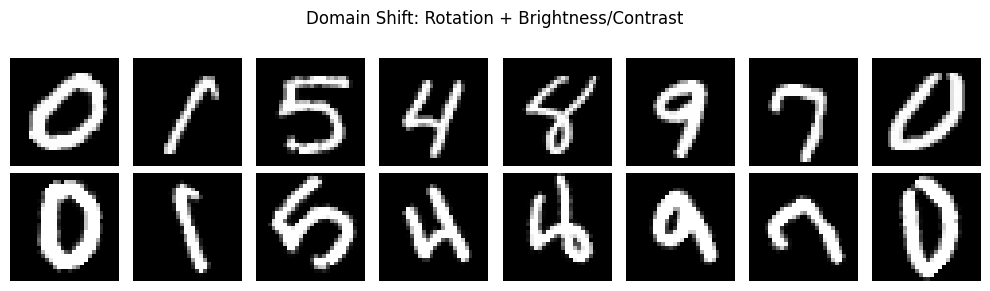

In [4]:
# =====================================
# 1. Setup and Data Preparation
# =====================================

# -------------------------
# Load MNIST
# -------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.astype(np.float32) / 255.0
X_test  = X_test.astype(np.float32) / 255.0

# Reshape to (batch, seq, feat) = (N, 28, 28) for RNN input
X_train = X_train.reshape(-1, 28, 28)
X_test  = X_test.reshape(-1, 28, 28)

N_TRAIN = 20000
N_TEST = 5000
SEED = 42
rng = np.random.default_rng(SEED)

train_idx = rng.choice(len(X_train), N_TRAIN, replace=False)
test_idx  = rng.choice(len(X_test), N_TEST, replace=False)

X_train, y_train = X_train[train_idx], y_train[train_idx]
X_test,  y_test  = X_test[test_idx],  y_test[test_idx]

X_train = jnp.array(X_train, dtype=jnp.float32)
X_test = jnp.array(X_test, dtype=jnp.float32)
y_train = jnp.array(y_train, dtype=jnp.int32)
y_test = jnp.array(y_test, dtype=jnp.int32)

print(f"Data loaded:")
print(f"  Train: {X_train.shape}, dtype={X_train.dtype}")
print(f"  Test: {X_test.shape}, dtype={X_test.dtype}")

# -------------------------
# Domain Shift Function
# -------------------------
def apply_domain_shift(
    X: np.ndarray,
    rotation_angle: float | None = None,
    contrast: float | None = None,
    brightness: float | None = None,
) -> np.ndarray:
    """
    Apply geometric (rotation) and photometric (brightness/contrast) shifts.
    - X: (N, 28, 28) images, values in [0,1]
    - rotation_angle: degrees, e.g., 15 or 30
    - contrast: multiplier (>1 = stronger contrast)
    - brightness: additive shift (>0 = brighter)
    """
    X_shifted = X.astype(np.float32).copy()

    # Rotation
    if rotation_angle is not None and rotation_angle != 0:
        X_shifted = np.array([
            rotate(img, rotation_angle, reshape=False, order=1, mode='constant', cval=0.0)
            for img in X_shifted
        ])

    # Brightness / contrast
    if contrast is not None or brightness is not None:
        c = contrast if contrast is not None else 1.0
        b = brightness if brightness is not None else 0.0
        X_shifted = np.clip(((X_shifted - 0.5) * c + 0.5) + b, 0, 1)

    return jnp.array(X_shifted, dtype=jnp.float32)

# -------------------------
# Define and apply the domain shift
# -------------------------
rotation_angle = 45      # degrees
contrast = 1.8
brightness = 0.4

X_train_shifted = apply_domain_shift(X_train, rotation_angle, contrast, brightness)
X_test_shifted  = apply_domain_shift(X_test,  rotation_angle, contrast, brightness)

y_train_shifted = y_train.copy()
y_test_shifted  = y_test.copy()

print(f"Train original: {X_train.shape}, shifted: {X_train_shifted.shape}")
print(f"Test  original: {X_test.shape},  shifted: {X_test_shifted.shape}")
print(f"Applied domain shift: rotation={rotation_angle}°, contrast={contrast}, brightness={brightness}")

# -------------------------
# Visualization
# -------------------------
fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for i in range(8):
    axes[0, i].imshow(X_test[i], cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(X_test_shifted[i], cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", rotation=0, labelpad=40)
axes[1, 0].set_ylabel("Shifted", rotation=0, labelpad=40)
plt.suptitle("Domain Shift: Rotation + Brightness/Contrast", fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
def summarize_nnx_model(model):
    from jax.flatten_util import ravel_pytree
    print("\n==============================")
    print(" MODEL SUMMARY (NNX) ")
    print("==============================")

    total_params = 0
    # RNN core
    for name, layer in model.params.items():
        flat_params, _ = ravel_pytree(nnx.state(layer, nnx.Param))
        n = flat_params.size
        total_params += n
        print(f"{name:15s}: {layer.in_features} → {layer.out_features} ({n:,} params)")

    # Classifier
    for name, layer in vars(model.classifier).items():
        if isinstance(layer, nnx.Linear):
            flat_params, _ = ravel_pytree(nnx.state(layer, nnx.Param))
            n = flat_params.size
            total_params += n
            print(f"classifier.{name:7s}: {layer.in_features} → {layer.out_features} ({n:,} params)")

    print("-" * 50)
    print(f"Total parameters: {total_params:,}")
    print("==============================\n")
rngs = nnx.Rngs(0)
model = TwoLayerRNNFunctional(input_dim=28, hidden_dim=64, num_classes=10, rngs=rngs)
summarize_nnx_model(model)


 MODEL SUMMARY (NNX) 
Wxh1           : 28 → 64 (1,856 params)
Whh1           : 64 → 64 (4,160 params)
Wxh2           : 64 → 64 (4,160 params)
Whh2           : 64 → 64 (4,160 params)
classifier.fc1    : 64 → 32 (2,080 params)
classifier.fc2    : 32 → 10 (330 params)
--------------------------------------------------
Total parameters: 16,746



In [6]:
# =====================================
# 4. TrainState Utilities for RNN (NNX Compatible)
# =====================================
from flax.training import train_state
from typing import Any

class TrainStateFull(train_state.TrainState):
    graphdef: Any = None
    other_states: Any = None

class TrainStateOutputOnly(train_state.TrainState):
    full_graphdef: Any = None
    output_graphdef: Any = None
    full_other_states: Any = None
    output_other_states: Any = None


# -------------------------
# Full Model TrainState
# -------------------------
def create_train_state_full(model, learning_rate):
    """
    Create TrainState for full RNN pretraining.
    """
    graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
    tx = optax.adam(learning_rate)

    def apply_fn(params, x, training=False):
        model_copy = nnx.merge(graphdef, params, other_states)
        return model_copy(x, is_training=training)

    return TrainStateFull.create(
        apply_fn=apply_fn,
        params=params,
        tx=tx,
        graphdef=graphdef,
        other_states=other_states
    )


# -------------------------
# Output Layer TrainState (Selective Adaptation)
# -------------------------
def create_train_state_output_only(model, learning_rate):
    """
    Create TrainState for fine-tuning only the classifier head (output layer).
    Keeps RNN core frozen and avoids stale dropout issues.
    """
    # Extract output (classifier) layer
    output_layer = model.classifier
    output_graphdef, output_params, output_other_states = nnx.split(output_layer, nnx.Param, ...)

    # Extract full model parts for feature extraction
    full_graphdef, full_params, full_other_states = nnx.split(model, nnx.Param, ...)

    tx = optax.adam(learning_rate)

    def apply_fn(output_params, x, training=False):
        # Build frozen feature extractor
        model_copy = nnx.merge(full_graphdef, full_params, full_other_states)
        features = model_copy.extract_features(x)
        # Apply trainable head
        output_layer_updated = nnx.merge(output_graphdef, output_params, output_other_states)
        logits = output_layer_updated(features)
        return logits

    return TrainStateOutputOnly.create(
        apply_fn=apply_fn,
        params=output_params,
        tx=tx,
        full_graphdef=full_graphdef,
        output_graphdef=output_graphdef,
        full_other_states=full_other_states,
        output_other_states=output_other_states
    )

In [7]:
# =====================================
# 5. Training and Evaluation Steps
# =====================================
from jax import jit

@jit
def pretrain_step(state, batch):
    x, y = batch
    def loss_fn(params):
        logits = state.apply_fn(params, x, training=True)
        return cross_entropy(logits, y)
    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    logits = state.apply_fn(state.params, x, training=False)
    acc = accuracy(logits, y)
    return state, loss, acc


@jit
def finetune_step(state, batch):
    x, y = batch
    def loss_fn(params):
        logits = state.apply_fn(params, x, training=False)
        return cross_entropy(logits, y)
    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    logits = state.apply_fn(state.params, x, training=False)
    acc = accuracy(logits, y)
    return state, loss, acc


@jit
def eval_step(state, batch):
    x, y = batch
    logits = state.apply_fn(state.params, x, training=False)
    loss = cross_entropy(logits, y)
    acc = accuracy(logits, y)
    return loss, acc

In [8]:
# =====================================
# 6. Baseline Pretraining (Two-Layer Functional RNN)
# =====================================
rngs = nnx.Rngs(0)
model = TwoLayerRNNFunctional(input_dim=28, hidden_dim=64, num_classes=10, rngs=rngs)

# Create train state for FULL model pretraining
state = create_train_state_full(model, learning_rate=1e-3)

epochs = 30
batch_size = 128
train_losses, train_accs, test_accs = [], [], []

print("\n==============================")
print(" Pretraining baseline RNN (TrainState version)")
print("==============================")

n_batches = int(np.ceil(len(X_train) / batch_size))

for ep in range(epochs):
    key = jax.random.PRNGKey(ep)
    perm = jax.random.permutation(key, len(X_train))
    X_shuf, y_shuf = X_train[perm], y_train[perm]

    epoch_loss, epoch_acc = 0.0, 0.0

    # -----------------------------
    # Batch training loop
    # -----------------------------
    for i in range(n_batches):
        start, end = i * batch_size, min((i + 1) * batch_size, len(X_train))
        Xb, yb = X_shuf[start:end], y_shuf[start:end]
        state, loss, acc = pretrain_step(state, (Xb, yb))
        epoch_loss += float(loss)
        epoch_acc  += float(acc)

    epoch_loss /= n_batches
    epoch_acc  /= n_batches

    # -----------------------------
    # Evaluate on clean test set
    # -----------------------------
    test_loss, test_acc = eval_step(state, (X_test, y_test))
    test_loss, test_acc = float(test_loss), float(test_acc)

    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    test_accs.append(test_acc)

    print(f"Epoch {ep+1:2d}/{epochs}: "
          f"train_loss={epoch_loss:.4f} "
          f"train_acc={epoch_acc:.4f} "
          f"test_acc={test_acc:.4f}")

# ------------------------------------------------------------
# Save the trained model (for adaptation)
# ------------------------------------------------------------
graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
trained_model = nnx.merge(graphdef, state.params, other_states)

# ------------------------------------------------------------
# Evaluate baseline under domain shift
# ------------------------------------------------------------
print("\n==============================")
print(" Evaluating baseline under domain shift")
print("==============================")

shifted_loss, shifted_acc = eval_step(state, (X_test_shifted, y_test_shifted))
baseline_acc_shift = float(shifted_acc)

print(f"Baseline accuracy (clean test):   {test_accs[-1]:.4f}")
print(f"Baseline accuracy (shifted test): {baseline_acc_shift:.4f}")
print(f"Accuracy drop due to shift:      {(test_accs[-1] - baseline_acc_shift):.4f}")

# ------------------------------------------------------------
# Save baseline for adaptation steps (e.g., selective fine-tuning)
# ------------------------------------------------------------
print("\nSaving pretrained baseline for adaptation...")
graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
baseline_model = nnx.merge(graphdef, params, other_states)
print("Baseline model snapshot created.")


 Pretraining baseline RNN (TrainState version)
Epoch  1/30: train_loss=1.4989 train_acc=0.5407 test_acc=0.6946
Epoch  2/30: train_loss=0.9174 train_acc=0.7513 test_acc=0.7764
Epoch  3/30: train_loss=0.7472 train_acc=0.8101 test_acc=0.8448
Epoch  4/30: train_loss=0.6580 train_acc=0.8500 test_acc=0.8700
Epoch  5/30: train_loss=0.5735 train_acc=0.8776 test_acc=0.8902
Epoch  6/30: train_loss=0.5205 train_acc=0.8848 test_acc=0.8830
Epoch  7/30: train_loss=0.4876 train_acc=0.8931 test_acc=0.8930
Epoch  8/30: train_loss=0.4660 train_acc=0.9002 test_acc=0.9116
Epoch  9/30: train_loss=0.4277 train_acc=0.9102 test_acc=0.9158
Epoch 10/30: train_loss=0.4108 train_acc=0.9148 test_acc=0.9206
Epoch 11/30: train_loss=0.3806 train_acc=0.9221 test_acc=0.9190
Epoch 12/30: train_loss=0.3837 train_acc=0.9219 test_acc=0.9264
Epoch 13/30: train_loss=0.3548 train_acc=0.9295 test_acc=0.9388
Epoch 14/30: train_loss=0.3331 train_acc=0.9359 test_acc=0.9434
Epoch 15/30: train_loss=0.3260 train_acc=0.9390 test_acc

In [9]:
# =====================================
# 7. Selective Fine-Tuning (Classifier Head Only)
# =====================================

print("\n" + "="*80)
print("SELECTIVE FINE-TUNING (Classifier Head Only, Adam)")
print("="*80)

# Clone baseline model to avoid overwriting pretrained weights
finetune_model = nnx.clone(baseline_model)

# Create train state for only the classifier head
ft_state = create_train_state_output_only(finetune_model, learning_rate=1e-3)

ft_epochs = 100
batch_size = 128
ft_losses, ft_accs, ft_test_accs = [], [], []

n_batches = int(np.ceil(len(X_train_shifted) / batch_size))
print(f"\nFine-tuning for {ft_epochs} epochs on shifted training data...")

start_time = time.time()

for ep in range(ft_epochs):
    key = jax.random.PRNGKey(ep + 999)
    perm = jax.random.permutation(key, len(X_train_shifted))
    X_shuf, y_shuf = X_train_shifted[perm], y_train_shifted[perm]

    epoch_loss, epoch_acc = 0.0, 0.0

    for i in range(n_batches):
        start, end = i * batch_size, min((i + 1) * batch_size, len(X_train_shifted))
        Xb, yb = X_shuf[start:end], y_shuf[start:end]
        ft_state, loss, acc = finetune_step(ft_state, (Xb, yb))
        epoch_loss += float(loss)
        epoch_acc  += float(acc)

    epoch_loss /= n_batches
    epoch_acc  /= n_batches
    ft_losses.append(epoch_loss)
    ft_accs.append(epoch_acc)

    # Evaluate on shifted test set
    test_loss, test_acc = eval_step(ft_state, (X_test_shifted, y_test_shifted))
    test_loss, test_acc = float(test_loss), float(test_acc)
    ft_test_accs.append(test_acc)

    if (ep + 1) % 10 == 0 or ep == ft_epochs - 1:
        print(f"Epoch {ep+1:2d}/{ft_epochs}: "
              f"train_loss={epoch_loss:.4f} train_acc={epoch_acc:.4f} test_acc={test_acc:.4f}")

ft_time = time.time() - start_time

# ------------------------------------------------------------
# Final evaluation
# ------------------------------------------------------------
final_loss, final_acc = eval_step(ft_state, (X_test_shifted, y_test_shifted))
final_loss, final_acc = float(final_loss), float(final_acc)
print(f"\nSelective fine-tuning final accuracy on shifted test data: {final_acc:.4f}")

ft_results = {
    'method': 'Adam-SelectiveFT',
    'train_losses': ft_losses,
    'train_accs': ft_accs,
    'test_accs': ft_test_accs,
    'final_loss': final_loss,
    'final_acc': final_acc,
    'epochs': ft_epochs,
    'time': ft_time,
    'model': finetune_model,
    'state': ft_state,
}

print(f"\nFine-tuning completed in {ft_time:.2f}s. Final acc={final_acc:.4f}")


SELECTIVE FINE-TUNING (Classifier Head Only, Adam)

Fine-tuning for 100 epochs on shifted training data...
Epoch 10/100: train_loss=1.0797 train_acc=0.6186 test_acc=0.6284
Epoch 20/100: train_loss=0.9687 train_acc=0.6615 test_acc=0.6670
Epoch 30/100: train_loss=0.9222 train_acc=0.6800 test_acc=0.6782
Epoch 40/100: train_loss=0.8949 train_acc=0.6912 test_acc=0.6864
Epoch 50/100: train_loss=0.8747 train_acc=0.6980 test_acc=0.6966
Epoch 60/100: train_loss=0.8592 train_acc=0.7044 test_acc=0.6998
Epoch 70/100: train_loss=0.8492 train_acc=0.7075 test_acc=0.7036
Epoch 80/100: train_loss=0.8389 train_acc=0.7102 test_acc=0.7082
Epoch 90/100: train_loss=0.8258 train_acc=0.7151 test_acc=0.7034
Epoch 100/100: train_loss=0.8168 train_acc=0.7169 test_acc=0.7100

Selective fine-tuning final accuracy on shifted test data: 0.7100

Fine-tuning completed in 41.69s. Final acc=0.7100


In [10]:
# =====================================
# 8. EKF Adaptation (Classifier Head Only)
# =====================================

print("\n" + "="*80)
print("EKF FINE-TUNING (Classifier Head Only)")
print("="*80)

# ------------------------------------------------------------
# Clone baseline and initialize
# ------------------------------------------------------------
ekf_model = nnx.clone(baseline_model)
classifier = ekf_model.classifier

cls_state = nnx.state(classifier, nnx.Param)
flat_params, unflatten_fn = ravel_pytree(cls_state)
dim = flat_params.size
print(f"Classifier head parameters: {dim}")

# ------------------------------------------------------------
# EKF hyperparameters
# ------------------------------------------------------------
prior_var = 0.1
dyn_sigma = 1e-6
obs_sigma = 1e-3
batch_size = 128
num_epochs = 1
Q = jnp.eye(dim) * dyn_sigma
R = jnp.eye(10) * obs_sigma

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def f_fn(w, x):
    """Static weights (no dynamics)."""
    return w

def emission_cov_fn(w, x):
    """Measurement noise covariance."""
    probs = emission_mean_fn(w, x)
    return jnp.diag(probs * (1 - probs)) + obs_sigma * jnp.eye(10)

# ------------------------------------------------------------
# Emission function with NNX state handling
# ------------------------------------------------------------
def emission_mean_fn(w, x):
    """
    Emission model returning probabilities.
    Handles batch dimension AND NNX VariableState access
    
    Args:
        w: flattened classifier parameters
        x: single sample (28, 28) from EKF - NO batch dimension
    Returns:
        probabilities (10,) for this single sample
    """
    # Unflatten parameters (returns NNX VariableState structure)
    params = unflatten_fn(w)
    
    # Access .value from VariableState objects
    W1 = params["fc1"]["kernel"].value  
    b1 = params["fc1"]["bias"].value
    W2 = params["fc2"]["kernel"].value
    b2 = params["fc2"]["bias"].value
    
    # EKF passes x with shape (28, 28), but extract_features expects (batch, 28, 28)
    x_batched = jnp.expand_dims(x, axis=0)  # Shape: (1, 28, 28)
    
    # Extract features using the RNN (returns shape (1, hidden_dim))
    features = ekf_model.extract_features(x_batched)
    
    # Remove batch dimension (squeeze to get (hidden_dim,))
    features_squeezed = jnp.squeeze(features, axis=0)
    
    # Forward through classifier head
    h = jax.nn.relu(jnp.dot(features_squeezed, W1) + b1)
    logits = jnp.dot(h, W2) + b2
    
    # Return probabilities 
    return jax.nn.softmax(logits)
# ------------------------------------------------------------
# Helper function for model evaluation
# ------------------------------------------------------------
def eval_model(model, X_batch, y_batch):
    """Evaluate model on a batch (avoids TrainState confusion)"""
    logits = model(X_batch, is_training=False)
    loss = cross_entropy(logits, y_batch)
    acc = accuracy(logits, y_batch)
    return loss, acc

# ------------------------------------------------------------
# Functional EKF update (batch as pseudo-sequence)
# ------------------------------------------------------------
def ekf_update(model, Xb, yb, P_prev=None, step=0):
    """
    Run EKF update on classifier head only.
    
    Args:
        model: TwoLayerRNNFunctional model
        Xb: batch of inputs (batch_size, 28, 28)
        yb: batch of labels (batch_size,)
        P_prev: previous covariance matrix (dim, dim) or None
        step: current step (for logging)
    
    Returns:
        model: updated model
        P_new: updated covariance matrix
    """
    classifier = model.classifier
    cls_state = nnx.state(classifier, nnx.Param)
    flat_params, unflatten_fn_local = ravel_pytree(cls_state)
    dim = flat_params.size

    # Initialize or use previous covariance
    if P_prev is None:
        w_mean = flat_params
        P = jnp.eye(dim) * prior_var
        print(f"  [EKF] Initialized covariance P0 ({dim}×{dim})")
    else:
        w_mean = flat_params  # Use current params as mean
        P = P_prev  
    
    # Add small regularization for numerical stability
    P = P + jnp.eye(dim) * 1e-8

    # Feature extraction (done once for the whole batch)
    y_onehot = jax.nn.one_hot(yb, 10)

    # Setup EKF parameters
    params = ParamsGGSSM(
        initial_mean=w_mean,
        initial_covariance=P,
        dynamics_function=f_fn,
        dynamics_covariance=Q,
        emission_mean_function=emission_mean_fn,
        emission_cov_function=emission_cov_fn,
    )

    # Run EKF filter (treats batch as sequence)
    # inputs=Xb passes each sample (28, 28) to emission_mean_fn
    posterior = conditional_moments_gaussian_filter(
        params, EKFIntegrals(), y_onehot, inputs=Xb
    )

    # Extract final posterior mean and covariance
    w_mean_new = posterior.filtered_means[-1]
    P_new = posterior.filtered_covariances[-1] + jnp.eye(dim) * 1e-8
    
    # Unflatten and update classifier
    updated_params = unflatten_fn_local(w_mean_new)
    
    #Assign the return value of nnx.update
    nnx.update(classifier, updated_params)

    return model, P_new

# ------------------------------------------------------------
# EKF Training Loop
# ------------------------------------------------------------
P_ekf = None
n_batches = int(np.ceil(len(X_train_shifted) / batch_size))
start_time = time.time()

for ep in range(num_epochs):
    key = jax.random.PRNGKey(9999 + ep)
    perm = jax.random.permutation(key, len(X_train_shifted))
    X_shuf, y_shuf = X_train_shifted[perm], y_train_shifted[perm]

    epoch_loss, epoch_acc = 0.0, 0.0

    for i in range(n_batches):
        start, end = i * batch_size, min((i + 1) * batch_size, len(X_shuf))
        Xb, yb = X_shuf[start:end], y_shuf[start:end]

        # Run EKF update
        ekf_model, P_ekf = ekf_update(
            ekf_model, Xb, yb, P_prev=P_ekf, step=i
        )

        # Evaluate the EKF model (not the baseline state)
        loss, acc = eval_model(ekf_model, Xb, yb)
        epoch_loss += float(loss)
        epoch_acc += float(acc)

        if (i + 1) % 50 == 0 or i == n_batches - 1:
            print(f"  Batch {i+1}/{n_batches}: loss={float(loss):.4f}, acc={float(acc):.4f}")

    epoch_loss /= n_batches
    epoch_acc /= n_batches

    #  Evaluate on test set using the EKF model
    test_loss, test_acc = eval_model(ekf_model, X_test_shifted, y_test_shifted)
    
    print(f"Epoch {ep+1}/{num_epochs}: train_loss={epoch_loss:.4f}, "
          f"train_acc={epoch_acc:.4f}, test_loss={float(test_loss):.4f}, test_acc={float(test_acc):.4f}")

ekf_time = time.time() - start_time

# ------------------------------------------------------------
# Final Evaluation and Logging
# ------------------------------------------------------------
final_loss, final_acc = eval_model(ekf_model, X_test_shifted, y_test_shifted)
ekf_results = {
    "method": "EKF-Functional",
    "final_loss": float(final_loss),
    "final_acc": float(final_acc),
    "epochs": num_epochs,
    "time": ekf_time,
    "model": ekf_model,
    "covariance": P_ekf,
}

print(f"\nEKF Final Accuracy: {float(final_acc):.4f}, Time: {ekf_time:.2f}s")
print("EKF functional adaptation completed successfully.")


EKF FINE-TUNING (Classifier Head Only)
Classifier head parameters: 2410
  [EKF] Initialized covariance P0 (2410×2410)
  Batch 50/157: loss=0.7789, acc=0.7656
  Batch 100/157: loss=0.6275, acc=0.8281
  Batch 150/157: loss=0.7007, acc=0.7500
  Batch 157/157: loss=0.8542, acc=0.6562
Epoch 1/1: train_loss=0.7745, train_acc=0.7571, test_loss=0.7775, test_acc=0.7374

EKF Final Accuracy: 0.7374, Time: 769.19s
EKF functional adaptation completed successfully.


In [11]:
# =====================================
# DEKF Adaptation (Classifier Head Only)
# =====================================
from jax.flatten_util import ravel_pytree
from dynamax.generalized_gaussian_ssm.models import ParamsGGSSM
from dynamax.generalized_gaussian_ssm.inference import conditional_moments_gaussian_filter, EKFIntegrals
import time

print("\n" + "="*80)
print("DEKF FINE-TUNING (Classifier Head Only)")
print("="*80)

# ------------------------------------------------------------
# Clone baseline and initialize
# ------------------------------------------------------------
dekf_model = nnx.clone(baseline_model)
classifier = dekf_model.classifier

# Get fc1 and fc2 parameters
fc1_state = nnx.state(classifier.fc1, nnx.Param)
fc2_state = nnx.state(classifier.fc2, nnx.Param)

fc1_flat, fc1_unflatten = ravel_pytree(fc1_state)
fc2_flat, fc2_unflatten = ravel_pytree(fc2_state)

fc1_dim = fc1_flat.size
fc2_dim = fc2_flat.size

print(f"FC1 parameters: {fc1_dim}")
print(f"FC2 parameters: {fc2_dim}")
print(f"Total classifier parameters: {fc1_dim + fc2_dim}")

# ------------------------------------------------------------
# DEKF hyperparameters
# ------------------------------------------------------------
prior_var = 0.1
dyn_sigma = 1e-6
obs_sigma = 1e-3
batch_size = 128
num_epochs = 1

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def f_fn(w, x):
    """Static weights (no dynamics)."""
    return w

def eval_model(model, X_batch, y_batch):
    """Evaluate model on a batch"""
    logits = model(X_batch, is_training=False)
    loss = cross_entropy(logits, y_batch)
    acc = accuracy(logits, y_batch)
    return loss, acc

# ------------------------------------------------------------
# DEKF update: Update fc1 and fc2 separately
# ------------------------------------------------------------
def dekf_update(model, Xb, yb, P_fc1_prev=None, P_fc2_prev=None, step=0):
    """
    Run DEKF update: fc1 first, then fc2 (sequentially).
    
    Args:
        model: TwoLayerRNNFunctional model
        Xb: batch of inputs (batch_size, 28, 28)
        yb: batch of labels (batch_size,)
        P_fc1_prev: previous covariance for fc1 or None
        P_fc2_prev: previous covariance for fc2 or None
        step: current step
    
    Returns:
        model: updated model
        P_fc1_new: updated fc1 covariance
        P_fc2_new: updated fc2 covariance
    """
    classifier = model.classifier
    y_onehot = jax.nn.one_hot(yb, 10)
    
    # ========================================
    # Step 1: Update fc1 (freeze fc2)
    # ========================================
    
    # Get fc1 parameters
    fc1_state = nnx.state(classifier.fc1, nnx.Param)
    fc1_flat, fc1_unflatten = ravel_pytree(fc1_state)
    fc1_dim = fc1_flat.size
    
    # Initialize fc1 covariance
    if P_fc1_prev is None:
        P_fc1 = jnp.eye(fc1_dim) * prior_var
        print(f"  [DEKF] Initialized fc1 covariance: ({fc1_dim}×{fc1_dim})")
    else:
        P_fc1 = P_fc1_prev + jnp.eye(fc1_dim) * 1e-8
    
    # Emission function for fc1 (reads current state each time)
    def emission_mean_fn_fc1(w_fc1, x):
        """
        Update fc1 while keeping fc2 frozen.
        """
        # Unflatten fc1 parameters
        params_fc1 = fc1_unflatten(w_fc1)
        
        # Create temporary fc1 with these parameters
        fc1_temp_graphdef, _, fc1_other_states = nnx.split(classifier.fc1, nnx.Param, ...)
        fc1_temp = nnx.merge(fc1_temp_graphdef, params_fc1, fc1_other_states)
        
        # Add batch dimension for extract_features
        x_batched = jnp.expand_dims(x, axis=0)  # (1, 28, 28)
        features = model.extract_features(x_batched)  # (1, hidden_dim)
        features_squeezed = jnp.squeeze(features, axis=0)  # (hidden_dim,)
        
        # Forward through temporary fc1
        h = jax.nn.relu(fc1_temp(features_squeezed))
        
        # Forward through frozen fc2
        logits = classifier.fc2(h)
        
        return jax.nn.softmax(logits)
    
    def emission_cov_fn_fc1(w, x):
        """Measurement noise for fc1 update"""
        probs = emission_mean_fn_fc1(w, x)
        return jnp.diag(probs * (1 - probs)) + obs_sigma * jnp.eye(10)
    
    # Setup EKF for fc1
    Q_fc1 = jnp.eye(fc1_dim) * dyn_sigma
    
    params_fc1_ggssm = ParamsGGSSM(
        initial_mean=fc1_flat,
        initial_covariance=P_fc1,
        dynamics_function=f_fn,
        dynamics_covariance=Q_fc1,
        emission_mean_function=emission_mean_fn_fc1,
        emission_cov_function=emission_cov_fn_fc1,
    )
    
    # Run EKF for fc1
    posterior_fc1 = conditional_moments_gaussian_filter(
        params_fc1_ggssm, EKFIntegrals(), y_onehot, inputs=Xb
    )
    
    fc1_mean_new = posterior_fc1.filtered_means[-1]
    P_fc1_new = posterior_fc1.filtered_covariances[-1] + jnp.eye(fc1_dim) * 1e-8
    
    # Update fc1 in the model 
    updated_fc1_params = fc1_unflatten(fc1_mean_new)
    nnx.update(classifier.fc1, updated_fc1_params)
    
    # ========================================
    # Step 2: Update fc2 (with updated fc1)
    # ========================================
    
    # Get fc2 parameters (fc1 is now updated)
    fc2_state = nnx.state(classifier.fc2, nnx.Param)
    fc2_flat, fc2_unflatten = ravel_pytree(fc2_state)
    fc2_dim = fc2_flat.size
    
    # Initialize fc2 covariance
    if P_fc2_prev is None:
        P_fc2 = jnp.eye(fc2_dim) * prior_var * 0.1  # Smaller for output layer
        print(f"  [DEKF] Initialized fc2 covariance: ({fc2_dim}×{fc2_dim})")
    else:
        P_fc2 = P_fc2_prev + jnp.eye(fc2_dim) * 1e-8
    
    # Emission function for fc2 (reads current updated fc1)
    def emission_mean_fn_fc2(w_fc2, x):
        """
        Update fc2 with updated fc1.
        """
        # Unflatten fc2 parameters
        params_fc2 = fc2_unflatten(w_fc2)
        
        # Create temporary fc2 with these parameters
        fc2_temp_graphdef, _, fc2_other_states = nnx.split(classifier.fc2, nnx.Param, ...)
        fc2_temp = nnx.merge(fc2_temp_graphdef, params_fc2, fc2_other_states)
        
        # Add batch dimension for extract_features
        x_batched = jnp.expand_dims(x, axis=0)  # (1, 28, 28)
        features = model.extract_features(x_batched)  # (1, hidden_dim)
        features_squeezed = jnp.squeeze(features, axis=0)  # (hidden_dim,)
        
        # Forward through UPDATED fc1
        h = jax.nn.relu(classifier.fc1(features_squeezed))
        
        # Forward through temporary fc2
        logits = fc2_temp(h)
        
        return jax.nn.softmax(logits)
    
    def emission_cov_fn_fc2(w, x):
        """Measurement noise for fc2 update"""
        probs = emission_mean_fn_fc2(w, x)
        return jnp.diag(probs * (1 - probs)) + obs_sigma * jnp.eye(10)
    
    # Setup EKF for fc2
    Q_fc2 = jnp.eye(fc2_dim) * dyn_sigma * 0.1  # Smaller dynamics noise for output
    
    params_fc2_ggssm = ParamsGGSSM(
        initial_mean=fc2_flat,
        initial_covariance=P_fc2,
        dynamics_function=f_fn,
        dynamics_covariance=Q_fc2,
        emission_mean_function=emission_mean_fn_fc2,
        emission_cov_function=emission_cov_fn_fc2,
    )
    
    # Run EKF for fc2
    posterior_fc2 = conditional_moments_gaussian_filter(
        params_fc2_ggssm, EKFIntegrals(), y_onehot, inputs=Xb
    )
    
    fc2_mean_new = posterior_fc2.filtered_means[-1]
    P_fc2_new = posterior_fc2.filtered_covariances[-1] + jnp.eye(fc2_dim) * 1e-8
    
    # Update fc2 in the model 
    updated_fc2_params = fc2_unflatten(fc2_mean_new)
    nnx.update(classifier.fc2, updated_fc2_params)
    
    return model, P_fc1_new, P_fc2_new

# ------------------------------------------------------------
# DEKF Training Loop
# ------------------------------------------------------------
P_fc1 = None
P_fc2 = None
n_batches = int(np.ceil(len(X_train_shifted) / batch_size))
start_time = time.time()

for ep in range(num_epochs):
    key = jax.random.PRNGKey(9999 + ep)
    perm = jax.random.permutation(key, len(X_train_shifted))
    X_shuf, y_shuf = X_train_shifted[perm], y_train_shifted[perm]

    epoch_loss, epoch_acc = 0.0, 0.0

    for i in range(n_batches):
        start, end = i * batch_size, min((i + 1) * batch_size, len(X_shuf))
        Xb, yb = X_shuf[start:end], y_shuf[start:end]

        # Run DEKF update
        dekf_model, P_fc1, P_fc2 = dekf_update(
            dekf_model, Xb, yb, P_fc1_prev=P_fc1, P_fc2_prev=P_fc2, step=i
        )

        # Evaluate the DEKF model
        loss, acc = eval_model(dekf_model, Xb, yb)
        epoch_loss += float(loss)
        epoch_acc += float(acc)

        if (i + 1) % 50 == 0 or i == n_batches - 1:
            trace_fc1 = float(jnp.trace(P_fc1))
            trace_fc2 = float(jnp.trace(P_fc2))
            print(f"  Batch {i+1}/{n_batches}: loss={float(loss):.4f}, acc={float(acc):.4f}, "
                  f"Tr(P_fc1)={trace_fc1:.2e}, Tr(P_fc2)={trace_fc2:.2e}")

    epoch_loss /= n_batches
    epoch_acc /= n_batches

    # Evaluate on test set using the DEKF model
    test_loss, test_acc = eval_model(dekf_model, X_test_shifted, y_test_shifted)
    
    trace_fc1 = float(jnp.trace(P_fc1))
    trace_fc2 = float(jnp.trace(P_fc2))
    
    print(f"Epoch {ep+1}/{num_epochs}: train_loss={epoch_loss:.4f}, "
          f"train_acc={epoch_acc:.4f}, test_loss={float(test_loss):.4f}, test_acc={float(test_acc):.4f}")
    print(f"  Tr(P_fc1)={trace_fc1:.2e}, Tr(P_fc2)={trace_fc2:.2e}")

dekf_time = time.time() - start_time

# ------------------------------------------------------------
# Final Evaluation and Logging
# ------------------------------------------------------------
final_loss, final_acc = eval_model(dekf_model, X_test_shifted, y_test_shifted)
dekf_results = {
    "method": "DEKF-Functional",
    "final_loss": float(final_loss),
    "final_acc": float(final_acc),
    "epochs": num_epochs,
    "time": dekf_time,
    "model": dekf_model,
    "covariances": {"fc1": P_fc1, "fc2": P_fc2},
}

print(f"\nDEKF Final Accuracy: {float(final_acc):.4f}, Time: {dekf_time:.2f}s")
print("DEKF functional adaptation completed successfully.")


DEKF FINE-TUNING (Classifier Head Only)
FC1 parameters: 2080
FC2 parameters: 330
Total classifier parameters: 2410
  [DEKF] Initialized fc1 covariance: (2080×2080)
  [DEKF] Initialized fc2 covariance: (330×330)
  Batch 50/157: loss=0.8403, acc=0.7109, Tr(P_fc1)=1.73e+02, Tr(P_fc2)=2.23e+00
  Batch 100/157: loss=0.6887, acc=0.7891, Tr(P_fc1)=1.65e+02, Tr(P_fc2)=1.98e+00
  Batch 150/157: loss=0.7977, acc=0.7031, Tr(P_fc1)=1.60e+02, Tr(P_fc2)=1.87e+00
  Batch 157/157: loss=0.9016, acc=0.6250, Tr(P_fc1)=1.59e+02, Tr(P_fc2)=1.86e+00
Epoch 1/1: train_loss=0.8567, train_acc=0.7280, test_loss=0.8091, test_acc=0.7326
  Tr(P_fc1)=1.59e+02, Tr(P_fc2)=1.86e+00

DEKF Final Accuracy: 0.7326, Time: 1232.97s
DEKF functional adaptation completed successfully.


In [12]:
# =====================================
# LoRA Fine-tuning (Classifier Head Only)
# =====================================
import time

print("\n" + "="*80)
print("LORA FINE-TUNING (Classifier Head Only)")
print("="*80)

# ------------------------------------------------------------
# LoRA Hyperparameters
# ------------------------------------------------------------
lora_rank = 8
lora_alpha = 16.0
lora_lr = 5e-3
lora_epochs = 20
batch_size = 128

# ------------------------------------------------------------
# Create LoRA layers for fc1 and fc2
# ------------------------------------------------------------
def create_lora_classifier(base_classifier, rank, alpha, rngs):
    """
    Replace fc1 and fc2 with LoRA versions.
    
    Args:
        base_classifier: RNNClassifierHead with fc1 and fc2
        rank: LoRA rank
        alpha: LoRA alpha (scaling factor)
        rngs: Random number generators
    
    Returns:
        Modified classifier with LoRA layers
    """
    # Clone the base classifier
    lora_classifier = nnx.clone(base_classifier)
    
    # Replace fc1 with LoRA
    fc1_in = base_classifier.fc1.in_features
    fc1_out = base_classifier.fc1.out_features
    
    lora_fc1 = nnx.LoRALinear(
        in_features=fc1_in,
        out_features=fc1_out,
        lora_rank=rank,
        rngs=rngs
    )
    
    # Copy pretrained weights
    lora_fc1.kernel.value = base_classifier.fc1.kernel.value
    lora_fc1.bias.value = base_classifier.fc1.bias.value
    lora_fc1.lora_scale = alpha / rank
    
    lora_classifier.fc1 = lora_fc1
    
    # Replace fc2 with LoRA
    fc2_in = base_classifier.fc2.in_features
    fc2_out = base_classifier.fc2.out_features
    
    lora_fc2 = nnx.LoRALinear(
        in_features=fc2_in,
        out_features=fc2_out,
        lora_rank=rank,
        rngs=rngs
    )
    
    # Copy pretrained weights
    lora_fc2.kernel.value = base_classifier.fc2.kernel.value
    lora_fc2.bias.value = base_classifier.fc2.bias.value
    lora_fc2.lora_scale = alpha / rank
    
    lora_classifier.fc2 = lora_fc2
    
    print(f"  LoRA fc1: rank={rank}, alpha={alpha}, scale={alpha/rank:.4f}")
    print(f"  LoRA fc2: rank={rank}, alpha={alpha}, scale={alpha/rank:.4f}")
    
    return lora_classifier

# ------------------------------------------------------------
# Create LoRA model
# ------------------------------------------------------------
lora_rng = nnx.Rngs(42)
lora_model = nnx.clone(baseline_model)
lora_model.classifier = create_lora_classifier(
    baseline_model.classifier, lora_rank, lora_alpha, lora_rng
)

# ------------------------------------------------------------
# Filter for LoRA trainable parameters
# ------------------------------------------------------------
def is_lora_trainable(path, value):
    """Filter for LoRA-specific parameters (adapters + biases)"""
    path_str = '/'.join(str(p) for p in path)
    # Include LoRA adapters
    if 'lora' in path_str.lower():
        return True
    # Include biases in fc1 and fc2
    if ('fc1' in path_str or 'fc2' in path_str) and 'bias' in path_str:
        return True
    return False

# Split model into trainable and frozen parameters
graphdef, trainable_params, frozen_params = nnx.split(lora_model, is_lora_trainable, ...)

# Count parameters
def count_params(pytree):
    return sum(v.value.size if hasattr(v, 'value') else v.size
               for v in jax.tree.leaves(pytree))

all_state = nnx.state(lora_model, nnx.Param)
lora_count = count_params(trainable_params)
all_count = sum(v.size for v in jax.tree.leaves(all_state))

print(f"\nLoRA trainable params: {lora_count:,}")
print(f"Total model params: {all_count:,}")
print(f"LoRA efficiency: {100 * lora_count / all_count:.2f}%")

# ------------------------------------------------------------
# LoRA Training Step (JIT-compiled)
# ------------------------------------------------------------
tx = optax.adam(lora_lr)
opt_state = tx.init(trainable_params)

@jit
def lora_train_step(graphdef, trainable_params, frozen_params, opt_state, batch):
    """Pure, JIT-compiled LoRA training step"""
    x, y = batch
    
    def loss_fn(current_trainable_params):
        model_temp = nnx.merge(graphdef, current_trainable_params, frozen_params)
        logits = model_temp(x, is_training=False)  # No dropout in base RNN
        return cross_entropy(logits, y)
    
    # Compute loss and gradients
    loss, grads = jax.value_and_grad(loss_fn)(trainable_params)
    
    # Update trainable params
    updates, new_opt_state = tx.update(grads, opt_state, trainable_params)
    new_trainable_params = optax.apply_updates(trainable_params, updates)
    
    # Compute accuracy
    model_acc = nnx.merge(graphdef, new_trainable_params, frozen_params)
    logits_acc = model_acc(x, is_training=False)
    acc = accuracy(logits_acc, y)
    
    return new_trainable_params, new_opt_state, loss, acc

print("\nJIT-compiled LoRA training step defined")

# ------------------------------------------------------------
# LoRA Training Loop
# ------------------------------------------------------------
lora_losses, lora_accs = [], []
n_batches = int(np.ceil(len(X_train_shifted) / batch_size))
start_time = time.time()

for ep in range(lora_epochs):
    key = jax.random.PRNGKey(42 + ep)
    perm = jax.random.permutation(key, len(X_train_shifted))
    X_shuf = X_train_shifted[perm]
    y_shuf = y_train_shifted[perm]
    
    epoch_loss, epoch_acc = 0.0, 0.0
    
    for i in range(n_batches):
        start, end = i * batch_size, min((i + 1) * batch_size, len(X_train_shifted))
        Xb, yb = X_shuf[start:end], y_shuf[start:end]
        
        trainable_params, opt_state, loss, acc = lora_train_step(
            graphdef, trainable_params, frozen_params, opt_state, (Xb, yb)
        )
        
        lora_losses.append(float(loss))
        lora_accs.append(float(acc))
        
        epoch_loss += float(loss)
        epoch_acc += float(acc)
        
        if (i + 1) % 50 == 0 or i == n_batches - 1:
            print(f"  Batch {i+1}/{n_batches}: loss={float(loss):.4f}, acc={float(acc):.4f}")
    
    epoch_loss /= n_batches
    epoch_acc /= n_batches
    
    # Update model with current parameters
    updated_state = nnx.State.merge(trainable_params, frozen_params)
    nnx.update(lora_model, updated_state)
    
    # Evaluate on test set
    test_logits = lora_model(X_test_shifted, is_training=False)
    test_loss = cross_entropy(test_logits, y_test_shifted)
    test_acc = accuracy(test_logits, y_test_shifted)
    
    print(f"Epoch {ep+1}/{lora_epochs}: train_loss={epoch_loss:.4f}, "
          f"train_acc={epoch_acc:.4f}, test_loss={float(test_loss):.4f}, test_acc={float(test_acc):.4f}")

lora_time = time.time() - start_time

# ------------------------------------------------------------
# Final Evaluation
# ------------------------------------------------------------
final_logits = lora_model(X_test_shifted, is_training=False)
final_loss = cross_entropy(final_logits, y_test_shifted)
final_acc = accuracy(final_logits, y_test_shifted)

lora_results = {
    "method": "LoRA",
    "final_loss": float(final_loss),
    "final_acc": float(final_acc),
    "epochs": lora_epochs,
    "time": lora_time,
    "model": lora_model,
    "losses": lora_losses,
    "accs": lora_accs,
}

print(f"\nLoRA Final Accuracy: {float(final_acc):.4f}, Time: {lora_time:.2f}s")
print("LoRA fine-tuning completed successfully.")


LORA FINE-TUNING (Classifier Head Only)
  LoRA fc1: rank=8, alpha=16.0, scale=2.0000
  LoRA fc2: rank=8, alpha=16.0, scale=2.0000

LoRA trainable params: 1,146
Total model params: 17,850
LoRA efficiency: 6.42%

JIT-compiled LoRA training step defined
  Batch 50/157: loss=1.7397, acc=0.3828
  Batch 100/157: loss=1.5056, acc=0.4141
  Batch 150/157: loss=1.4737, acc=0.4688
  Batch 157/157: loss=1.4822, acc=0.4375
Epoch 1/20: train_loss=1.6446, train_acc=0.4132, test_loss=1.3233, test_acc=0.4998
  Batch 50/157: loss=1.2428, acc=0.5625
  Batch 100/157: loss=1.2696, acc=0.5625
  Batch 150/157: loss=1.0595, acc=0.6484
  Batch 157/157: loss=1.1132, acc=0.5938
Epoch 2/20: train_loss=1.2081, train_acc=0.5703, test_loss=1.1219, test_acc=0.6018
  Batch 50/157: loss=1.2802, acc=0.5703
  Batch 100/157: loss=1.0226, acc=0.6328
  Batch 150/157: loss=0.9007, acc=0.6406
  Batch 157/157: loss=1.0685, acc=0.7812
Epoch 3/20: train_loss=1.0784, train_acc=0.6240, test_loss=1.0515, test_acc=0.6268
  Batch 50

In [13]:
# =====================================
# LoRA-EKF Fine-tuning 
# =====================================
from jax.flatten_util import ravel_pytree
from dynamax.generalized_gaussian_ssm.models import ParamsGGSSM
from dynamax.generalized_gaussian_ssm.inference import conditional_moments_gaussian_filter, EKFIntegrals
import time

print("\n" + "="*80)
print("LORA-EKF FINE-TUNING ")
print("="*80)

# ------------------------------------------------------------
# Create LoRA model (reuse from previous LoRA section)
# ------------------------------------------------------------
lora_ekf_rng = nnx.Rngs(100)
lora_ekf_model = nnx.clone(baseline_model)

# Fixed function call (all positional arguments)
lora_ekf_model.classifier = create_lora_classifier(
    baseline_model.classifier, 8, 16.0, lora_ekf_rng
)

print(f"LoRA-EKF model created with rank=8, alpha=16.0")
# ------------------------------------------------------------
# LoRA-EKF hyperparameters
# ------------------------------------------------------------
prior_var = 0.1
dyn_sigma = 1e-4
obs_sigma = 1e-3
batch_size = 128
num_epochs = 1

# ------------------------------------------------------------
# Pre-compute features
# ------------------------------------------------------------
print("\nPre-computing RNN features for LoRA-EKF...")
train_features = lora_ekf_model.extract_features(X_train_shifted)
test_features = lora_ekf_model.extract_features(X_test_shifted)
print(f"Train features: {train_features.shape}")
print(f"Test features: {test_features.shape}")

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def f_fn(w, x):
    """Static weights (no dynamics)."""
    return w

# ------------------------------------------------------------
# LoRA-EKF update function
# ------------------------------------------------------------
def lora_ekf_update(model, features_batch, yb, P_prev=None, step=0):
    """
    Run EKF on LoRA parameters only (both fc1 and fc2).
    Base kernels remain frozen.
    
    """
    classifier = model.classifier
    
    # ========================================
    # Extract LoRA trainable parameters
    # ========================================
    
    # Get fc1 state
    fc1_state = nnx.state(classifier.fc1, nnx.Param)
    
    # Get fc2 state
    fc2_state = nnx.state(classifier.fc2, nnx.Param)
    
    # Extract trainable parameters (LoRA + bias) from both layers
    trainable_dict = {}
    
    # fc1 LoRA and bias
    if 'lora' in fc1_state:
        trainable_dict['fc1_lora'] = fc1_state['lora']
    if 'bias' in fc1_state:
        trainable_dict['fc1_bias'] = fc1_state['bias']
    
    # fc2 LoRA and bias
    if 'lora' in fc2_state:
        trainable_dict['fc2_lora'] = fc2_state['lora']
    if 'bias' in fc2_state:
        trainable_dict['fc2_bias'] = fc2_state['bias']
    
    # Flatten trainable params
    flat_params, unflatten_fn = ravel_pytree(trainable_dict)
    state_dim = flat_params.size
    
    if step == 0:
        print(f"  [LoRA-EKF] Trainable params: {state_dim} parameters")
        print(f"  [LoRA-EKF] Keys: {list(trainable_dict.keys())}")
    
    # Store frozen kernels
    frozen_kernel_fc1 = fc1_state['kernel']
    frozen_kernel_fc2 = fc2_state['kernel']
    
    # ========================================
    # Define emission function 
    # ========================================
    
    def emission_mean_fn(w, feature_vector):
        """
        Forward pass with LoRA parameters.
        
        Args:
            w: flattened LoRA parameters
            feature_vector: pre-computed RNN features (hidden_dim,)
        Returns:
            probabilities (10,)
        """
        # Unflatten trainable params
        params = unflatten_fn(w)
        
        # Reconstruct fc1 state: frozen kernel + trainable LoRA + bias
        fc1_temp_state = {'kernel': frozen_kernel_fc1}
        if 'fc1_lora' in params:
            fc1_temp_state['lora'] = params['fc1_lora']
        if 'fc1_bias' in params:
            fc1_temp_state['bias'] = params['fc1_bias']
        
        # Merge fc1
        fc1_graphdef, _, fc1_other_states = nnx.split(classifier.fc1, nnx.Param, ...)
        fc1_temp = nnx.merge(fc1_graphdef, fc1_temp_state, fc1_other_states)
        
        # Forward through fc1
        h = jax.nn.relu(fc1_temp(feature_vector))
        
        # Reconstruct fc2 state: frozen kernel + trainable LoRA + bias
        fc2_temp_state = {'kernel': frozen_kernel_fc2}
        if 'fc2_lora' in params:
            fc2_temp_state['lora'] = params['fc2_lora']
        if 'fc2_bias' in params:
            fc2_temp_state['bias'] = params['fc2_bias']
        
        # Merge fc2
        fc2_graphdef, _, fc2_other_states = nnx.split(classifier.fc2, nnx.Param, ...)
        fc2_temp = nnx.merge(fc2_graphdef, fc2_temp_state, fc2_other_states)
        
        # Forward through fc2
        logits = fc2_temp(h)
        
        return jax.nn.softmax(logits)
    
    def emission_cov_fn(w, feature_vector):
        probs = emission_mean_fn(w, feature_vector)
        return jnp.diag(probs * (1 - probs)) + obs_sigma * jnp.eye(10)
    
    # ========================================
    # Initialize covariance
    # ========================================
    
    if P_prev is None:
        initial_covariance = jnp.eye(state_dim) * prior_var
        print(f"  [LoRA-EKF] Initializing covariance: P0 = {prior_var} × I ({state_dim}×{state_dim})")
    else:
        initial_covariance = P_prev + jnp.eye(state_dim) * 1e-8
    
    # ========================================
    # Setup and run EKF
    # ========================================
    
    Q = jnp.eye(state_dim) * dyn_sigma
    
    params_ggssm = ParamsGGSSM(
        initial_mean=flat_params,
        initial_covariance=initial_covariance,
        dynamics_function=f_fn,
        dynamics_covariance=Q,
        emission_mean_function=emission_mean_fn,
        emission_cov_function=emission_cov_fn,
    )
    
    y_onehot = jax.nn.one_hot(yb, 10)
    
    # Run EKF filter
    posterior = conditional_moments_gaussian_filter(
        params_ggssm, EKFIntegrals(), y_onehot, inputs=features_batch
    )
    
    # Extract posterior
    updated_params_flat = posterior.filtered_means[-1]
    updated_covariance = posterior.filtered_covariances[-1] + jnp.eye(state_dim) * 1e-8
    
    # ========================================
    # Update model with new parameters
    # ========================================
    
    updated_params = unflatten_fn(updated_params_flat)
    
    # Update fc1
    if 'fc1_lora' in updated_params or 'fc1_bias' in updated_params:
        fc1_update_dict = {}
        if 'fc1_lora' in updated_params:
            fc1_update_dict['lora'] = updated_params['fc1_lora']
        if 'fc1_bias' in updated_params:
            fc1_update_dict['bias'] = updated_params['fc1_bias']
        nnx.update(classifier.fc1, fc1_update_dict)
    
    # Update fc2
    if 'fc2_lora' in updated_params or 'fc2_bias' in updated_params:
        fc2_update_dict = {}
        if 'fc2_lora' in updated_params:
            fc2_update_dict['lora'] = updated_params['fc2_lora']
        if 'fc2_bias' in updated_params:
            fc2_update_dict['bias'] = updated_params['fc2_bias']
        nnx.update(classifier.fc2, fc2_update_dict)
    
    return model, updated_covariance

# ------------------------------------------------------------
# LoRA-EKF Training Loop
# ------------------------------------------------------------
P_lora_ekf = None
n_batches = int(np.ceil(len(train_features) / batch_size))
start_time = time.time()

for ep in range(num_epochs):
    key = jax.random.PRNGKey(200 + ep)
    perm = jax.random.permutation(key, len(train_features))
    features_shuf = train_features[perm]
    y_shuf = y_train_shifted[perm]
    
    epoch_loss, epoch_acc = 0.0, 0.0
    
    for i in range(n_batches):
        start, end = i * batch_size, min((i + 1) * batch_size, len(train_features))
        features_b = features_shuf[start:end]
        yb = y_shuf[start:end]
        
        # Run LoRA-EKF update
        lora_ekf_model, P_lora_ekf = lora_ekf_update(
            lora_ekf_model, features_b, yb, P_prev=P_lora_ekf, step=i
        )
        
        # Evaluate
        logits = lora_ekf_model.classifier(features_b, is_training=False)
        loss = cross_entropy(logits, yb)
        acc = accuracy(logits, yb)
        
        epoch_loss += float(loss)
        epoch_acc += float(acc)
        
        if (i + 1) % 50 == 0 or i == n_batches - 1:
            trace_P = float(jnp.trace(P_lora_ekf))
            print(f"  Batch {i+1}/{n_batches}: loss={float(loss):.4f}, acc={float(acc):.4f}, "
                  f"Tr(P)={trace_P:.2e}")
    
    epoch_loss /= n_batches
    epoch_acc /= n_batches
    
    # Evaluate on test set
    test_logits = lora_ekf_model.classifier(test_features, is_training=False)
    test_loss = cross_entropy(test_logits, y_test_shifted)
    test_acc = accuracy(test_logits, y_test_shifted)
    
    print(f"Epoch {ep+1}/{num_epochs}: train_loss={epoch_loss:.4f}, "
          f"train_acc={epoch_acc:.4f}, test_loss={float(test_loss):.4f}, test_acc={float(test_acc):.4f}")

lora_ekf_time = time.time() - start_time

# ------------------------------------------------------------
# Final Evaluation
# ------------------------------------------------------------
final_logits = lora_ekf_model.classifier(test_features, is_training=False)
final_loss = cross_entropy(final_logits, y_test_shifted)
final_acc = accuracy(final_logits, y_test_shifted)

lora_ekf_results = {
    "method": "LoRA-EKF",
    "final_loss": float(final_loss),
    "final_acc": float(final_acc),
    "epochs": num_epochs,
    "time": lora_ekf_time,
    "model": lora_ekf_model,
    "covariance": P_lora_ekf,
}

print(f"\nLoRA-EKF Final Accuracy: {float(final_acc):.4f}, Time: {lora_ekf_time:.2f}s")
print("LoRA-EKF fine-tuning completed successfully.")


LORA-EKF FINE-TUNING 
  LoRA fc1: rank=8, alpha=16.0, scale=2.0000
  LoRA fc2: rank=8, alpha=16.0, scale=2.0000
LoRA-EKF model created with rank=8, alpha=16.0

Pre-computing RNN features for LoRA-EKF...
Train features: (20000, 64)
Test features: (5000, 64)
  [LoRA-EKF] Trainable params: 1146 parameters
  [LoRA-EKF] Keys: ['fc1_lora', 'fc1_bias', 'fc2_lora', 'fc2_bias']
  [LoRA-EKF] Initializing covariance: P0 = 0.1 × I (1146×1146)
  Batch 50/157: loss=0.6553, acc=0.8203, Tr(P)=2.54e+02
  Batch 100/157: loss=0.4543, acc=0.8672, Tr(P)=2.97e+02
  Batch 150/157: loss=0.6988, acc=0.7656, Tr(P)=3.15e+02
  Batch 157/157: loss=0.6670, acc=0.9062, Tr(P)=3.15e+02
Epoch 1/1: train_loss=0.6541, train_acc=0.8126, test_loss=1.1892, test_acc=0.5788

LoRA-EKF Final Accuracy: 0.5788, Time: 181.61s
LoRA-EKF fine-tuning completed successfully.


In [14]:
# =====================================
# LoRA-DEKF Fine-tuning
# =====================================
from jax.flatten_util import ravel_pytree
from dynamax.generalized_gaussian_ssm.models import ParamsGGSSM
from dynamax.generalized_gaussian_ssm.inference import conditional_moments_gaussian_filter, EKFIntegrals
import time

print("\n" + "="*80)
print("LORA-DEKF FINE-TUNING")
print("="*80)

# ------------------------------------------------------------
# Create LoRA model
# ------------------------------------------------------------
lora_dekf_rng = nnx.Rngs(300)
lora_dekf_model = nnx.clone(baseline_model)
lora_dekf_model.classifier = create_lora_classifier(
    baseline_model.classifier, 8, 16.0, lora_dekf_rng
)

print(f"LoRA-DEKF model created with rank=8, alpha=16.0")

# ------------------------------------------------------------
# LoRA-DEKF hyperparameters
# ------------------------------------------------------------
prior_var = 0.1
dyn_sigma = 1e-4
obs_sigma = 1e-3
batch_size = 128
num_epochs = 1

# ------------------------------------------------------------
# Pre-compute features
# ------------------------------------------------------------
print("\nPre-computing RNN features for LoRA-DEKF...")
train_features = lora_dekf_model.extract_features(X_train_shifted)
test_features = lora_dekf_model.extract_features(X_test_shifted)
print(f"Train features: {train_features.shape}")
print(f"Test features: {test_features.shape}")

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def f_fn(w, x):
    """Static weights (no dynamics)."""
    return w

# ------------------------------------------------------------
# LoRA-DEKF update function (Sequential: fc1 → fc2)
# ------------------------------------------------------------
def lora_dekf_update(model, features_batch, yb, P_fc1_prev=None, P_fc2_prev=None, step=0):
    """
    Run DEKF on LoRA parameters: update fc1 LoRA, then fc2 LoRA separately.
    Base kernels remain frozen.
    
    """
    classifier = model.classifier
    y_onehot = jax.nn.one_hot(yb, 10)
    
    # ========================================
    # Step 1: Update fc1 LoRA (freeze fc2)
    # ========================================
    
    # Get fc1 state
    fc1_state = nnx.state(classifier.fc1, nnx.Param)
    
    # Extract fc1 LoRA trainable parameters
    fc1_trainable = {}
    if 'lora' in fc1_state:
        fc1_trainable['lora'] = fc1_state['lora']
    if 'bias' in fc1_state:
        fc1_trainable['bias'] = fc1_state['bias']
    
    # Flatten fc1 trainable params
    fc1_flat, fc1_unflatten = ravel_pytree(fc1_trainable)
    fc1_dim = fc1_flat.size
    
    if step == 0:
        print(f"  [LoRA-DEKF] fc1 trainable params: {fc1_dim}")
    
    # Store frozen fc1 kernel
    frozen_kernel_fc1 = fc1_state['kernel']
    
    # Initialize fc1 covariance
    if P_fc1_prev is None:
        P_fc1 = jnp.eye(fc1_dim) * prior_var
        print(f"  [LoRA-DEKF] Initialized fc1 covariance: ({fc1_dim}×{fc1_dim})")
    else:
        P_fc1 = P_fc1_prev + jnp.eye(fc1_dim) * 1e-8
    
    # Emission function for fc1 (with frozen fc2)
    def emission_mean_fn_fc1(w_fc1, feature_vector):
        """Update fc1 LoRA while keeping fc2 frozen"""
        # Unflatten fc1 params
        params_fc1 = fc1_unflatten(w_fc1)
        
        # Reconstruct fc1 state: frozen kernel + trainable LoRA + bias
        fc1_temp_state = {'kernel': frozen_kernel_fc1}
        if 'lora' in params_fc1:
            fc1_temp_state['lora'] = params_fc1['lora']
        if 'bias' in params_fc1:
            fc1_temp_state['bias'] = params_fc1['bias']
        
        # Merge fc1
        fc1_graphdef, _, fc1_other_states = nnx.split(classifier.fc1, nnx.Param, ...)
        fc1_temp = nnx.merge(fc1_graphdef, fc1_temp_state, fc1_other_states)
        
        # Forward through fc1
        h = jax.nn.relu(fc1_temp(feature_vector))
        
        # Forward through FROZEN fc2
        logits = classifier.fc2(h)
        
        return jax.nn.softmax(logits)
    
    def emission_cov_fn_fc1(w, x):
        probs = emission_mean_fn_fc1(w, x)
        return jnp.diag(probs * (1 - probs)) + obs_sigma * jnp.eye(10)
    
    # Setup EKF for fc1
    Q_fc1 = jnp.eye(fc1_dim) * dyn_sigma
    
    params_fc1_ggssm = ParamsGGSSM(
        initial_mean=fc1_flat,
        initial_covariance=P_fc1,
        dynamics_function=f_fn,
        dynamics_covariance=Q_fc1,
        emission_mean_function=emission_mean_fn_fc1,
        emission_cov_function=emission_cov_fn_fc1,
    )
    
    # Run EKF for fc1
    posterior_fc1 = conditional_moments_gaussian_filter(
        params_fc1_ggssm, EKFIntegrals(), y_onehot, inputs=features_batch
    )
    
    fc1_mean_new = posterior_fc1.filtered_means[-1]
    P_fc1_new = posterior_fc1.filtered_covariances[-1] + jnp.eye(fc1_dim) * 1e-8
    
    # Update fc1 in the model
    updated_fc1_params = fc1_unflatten(fc1_mean_new)
    if 'lora' in updated_fc1_params:
        nnx.update(classifier.fc1, {'lora': updated_fc1_params['lora']})
    if 'bias' in updated_fc1_params:
        nnx.update(classifier.fc1, {'bias': updated_fc1_params['bias']})
    
    # ========================================
    # Step 2: Update fc2 LoRA (with updated fc1)
    # ========================================
    
    # Get fc2 state
    fc2_state = nnx.state(classifier.fc2, nnx.Param)
    
    # Extract fc2 LoRA trainable parameters
    fc2_trainable = {}
    if 'lora' in fc2_state:
        fc2_trainable['lora'] = fc2_state['lora']
    if 'bias' in fc2_state:
        fc2_trainable['bias'] = fc2_state['bias']
    
    # Flatten fc2 trainable params
    fc2_flat, fc2_unflatten = ravel_pytree(fc2_trainable)
    fc2_dim = fc2_flat.size
    
    if step == 0:
        print(f"  [LoRA-DEKF] fc2 trainable params: {fc2_dim}")
    
    # Store frozen fc2 kernel
    frozen_kernel_fc2 = fc2_state['kernel']
    
    # Initialize fc2 covariance
    if P_fc2_prev is None:
        P_fc2 = jnp.eye(fc2_dim) * prior_var * 0.1  # Smaller for output layer
        print(f"  [LoRA-DEKF] Initialized fc2 covariance: ({fc2_dim}×{fc2_dim})")
    else:
        P_fc2 = P_fc2_prev + jnp.eye(fc2_dim) * 1e-8
    
    # Emission function for fc2 (with updated fc1)
    def emission_mean_fn_fc2(w_fc2, feature_vector):
        """Update fc2 LoRA with updated fc1"""
        # Unflatten fc2 params
        params_fc2 = fc2_unflatten(w_fc2)
        
        # Reconstruct fc2 state: frozen kernel + trainable LoRA + bias
        fc2_temp_state = {'kernel': frozen_kernel_fc2}
        if 'lora' in params_fc2:
            fc2_temp_state['lora'] = params_fc2['lora']
        if 'bias' in params_fc2:
            fc2_temp_state['bias'] = params_fc2['bias']
        
        # Merge fc2
        fc2_graphdef, _, fc2_other_states = nnx.split(classifier.fc2, nnx.Param, ...)
        fc2_temp = nnx.merge(fc2_graphdef, fc2_temp_state, fc2_other_states)
        
        # Forward through UPDATED fc1
        h = jax.nn.relu(classifier.fc1(feature_vector))
        
        # Forward through fc2
        logits = fc2_temp(h)
        
        return jax.nn.softmax(logits)
    
    def emission_cov_fn_fc2(w, x):
        probs = emission_mean_fn_fc2(w, x)
        return jnp.diag(probs * (1 - probs)) + obs_sigma * jnp.eye(10)
    
    # Setup EKF for fc2
    Q_fc2 = jnp.eye(fc2_dim) * dyn_sigma * 0.1  # Smaller dynamics noise
    
    params_fc2_ggssm = ParamsGGSSM(
        initial_mean=fc2_flat,
        initial_covariance=P_fc2,
        dynamics_function=f_fn,
        dynamics_covariance=Q_fc2,
        emission_mean_function=emission_mean_fn_fc2,
        emission_cov_function=emission_cov_fn_fc2,
    )
    
    # Run EKF for fc2
    posterior_fc2 = conditional_moments_gaussian_filter(
        params_fc2_ggssm, EKFIntegrals(), y_onehot, inputs=features_batch
    )
    
    fc2_mean_new = posterior_fc2.filtered_means[-1]
    P_fc2_new = posterior_fc2.filtered_covariances[-1] + jnp.eye(fc2_dim) * 1e-8
    
    # Update fc2 in the model
    updated_fc2_params = fc2_unflatten(fc2_mean_new)
    if 'lora' in updated_fc2_params:
        nnx.update(classifier.fc2, {'lora': updated_fc2_params['lora']})
    if 'bias' in updated_fc2_params:
        nnx.update(classifier.fc2, {'bias': updated_fc2_params['bias']})
    
    return model, P_fc1_new, P_fc2_new

# ------------------------------------------------------------
# LoRA-DEKF Training Loop
# ------------------------------------------------------------
P_fc1_lora = None
P_fc2_lora = None
n_batches = int(np.ceil(len(train_features) / batch_size))
start_time = time.time()

for ep in range(num_epochs):
    key = jax.random.PRNGKey(300 + ep)
    perm = jax.random.permutation(key, len(train_features))
    features_shuf = train_features[perm]
    y_shuf = y_train_shifted[perm]
    
    epoch_loss, epoch_acc = 0.0, 0.0
    
    for i in range(n_batches):
        start, end = i * batch_size, min((i + 1) * batch_size, len(train_features))
        features_b = features_shuf[start:end]
        yb = y_shuf[start:end]
        
        # Run LoRA-DEKF update
        lora_dekf_model, P_fc1_lora, P_fc2_lora = lora_dekf_update(
            lora_dekf_model, features_b, yb, 
            P_fc1_prev=P_fc1_lora, P_fc2_prev=P_fc2_lora, step=i
        )
        
        # Evaluate
        logits = lora_dekf_model.classifier(features_b, is_training=False)
        loss = cross_entropy(logits, yb)
        acc = accuracy(logits, yb)
        
        epoch_loss += float(loss)
        epoch_acc += float(acc)
        
        if (i + 1) % 50 == 0 or i == n_batches - 1:
            trace_fc1 = float(jnp.trace(P_fc1_lora))
            trace_fc2 = float(jnp.trace(P_fc2_lora))
            print(f"  Batch {i+1}/{n_batches}: loss={float(loss):.4f}, acc={float(acc):.4f}, "
                  f"Tr(P_fc1)={trace_fc1:.2e}, Tr(P_fc2)={trace_fc2:.2e}")
    
    epoch_loss /= n_batches
    epoch_acc /= n_batches
    
    # Evaluate on test set
    test_logits = lora_dekf_model.classifier(test_features, is_training=False)
    test_loss = cross_entropy(test_logits, y_test_shifted)
    test_acc = accuracy(test_logits, y_test_shifted)
    
    trace_fc1 = float(jnp.trace(P_fc1_lora))
    trace_fc2 = float(jnp.trace(P_fc2_lora))
    
    print(f"Epoch {ep+1}/{num_epochs}: train_loss={epoch_loss:.4f}, "
          f"train_acc={epoch_acc:.4f}, test_loss={float(test_loss):.4f}, test_acc={float(test_acc):.4f}")
    print(f"  Tr(P_fc1)={trace_fc1:.2e}, Tr(P_fc2)={trace_fc2:.2e}")

lora_dekf_time = time.time() - start_time

# ------------------------------------------------------------
# Final Evaluation
# ------------------------------------------------------------
final_logits = lora_dekf_model.classifier(test_features, is_training=False)
final_loss = cross_entropy(final_logits, y_test_shifted)
final_acc = accuracy(final_logits, y_test_shifted)

lora_dekf_results = {
    "method": "LoRA-DEKF",
    "final_loss": float(final_loss),
    "final_acc": float(final_acc),
    "epochs": num_epochs,
    "time": lora_dekf_time,
    "model": lora_dekf_model,
    "covariances": {"fc1": P_fc1_lora, "fc2": P_fc2_lora},
}

print(f"\nLoRA-DEKF Final Accuracy: {float(final_acc):.4f}, Time: {lora_dekf_time:.2f}s")
print("LoRA-DEKF fine-tuning completed successfully.")


LORA-DEKF FINE-TUNING
  LoRA fc1: rank=8, alpha=16.0, scale=2.0000
  LoRA fc2: rank=8, alpha=16.0, scale=2.0000
LoRA-DEKF model created with rank=8, alpha=16.0

Pre-computing RNN features for LoRA-DEKF...
Train features: (20000, 64)
Test features: (5000, 64)
  [LoRA-DEKF] fc1 trainable params: 800
  [LoRA-DEKF] Initialized fc1 covariance: (800×800)
  [LoRA-DEKF] fc2 trainable params: 346
  [LoRA-DEKF] Initialized fc2 covariance: (346×346)
  Batch 50/157: loss=0.5700, acc=0.8438, Tr(P_fc1)=1.35e+02, Tr(P_fc2)=1.32e+01
  Batch 100/157: loss=1.1129, acc=0.6484, Tr(P_fc1)=1.34e+02, Tr(P_fc2)=2.01e+01
  Batch 150/157: loss=1.1266, acc=0.5859, Tr(P_fc1)=1.87e+02, Tr(P_fc2)=2.68e+01
  Batch 157/157: loss=1.2759, acc=0.5938, Tr(P_fc1)=1.92e+02, Tr(P_fc2)=2.75e+01
Epoch 1/1: train_loss=0.9068, train_acc=0.7273, test_loss=1.8493, test_acc=0.3912
  Tr(P_fc1)=1.92e+02, Tr(P_fc2)=2.75e+01

LoRA-DEKF Final Accuracy: 0.3912, Time: 278.26s
LoRA-DEKF fine-tuning completed successfully.


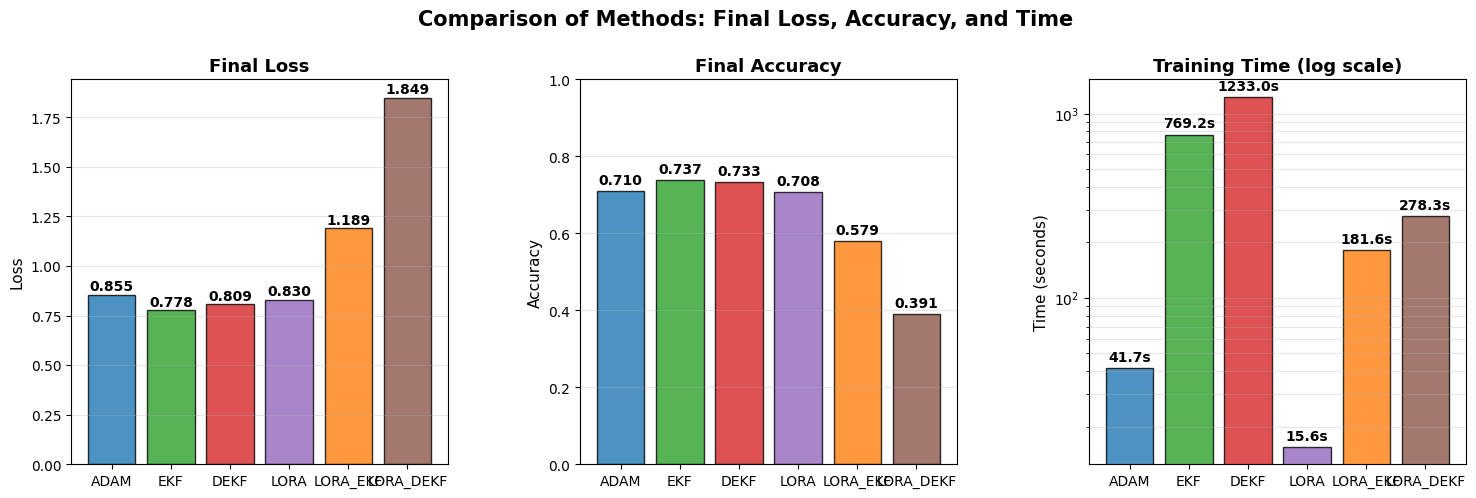

In [15]:
# ============================================================================
# SIMPLIFIED RESULTS VISUALIZATION (FINAL LOSS, ACCURACY, TIME)
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np

# Use your actual experiment result variables
results = {
    'adam': ft_results,
    'ekf': ekf_results,
    'dekf': dekf_results,
    'lora': lora_results,
    'lora_ekf': lora_ekf_results,
    'lora_dekf': lora_dekf_results
}

def plot_summary_results(results):
    """Plot bar charts for final loss, accuracy, and time across methods."""
    methods = list(results.keys())
    labels = [m.upper() for m in methods]

    # Extract metrics safely (handles missing keys)
    losses = [results[m].get('final_loss', np.nan) for m in methods]
    accs = [results[m].get('final_acc', np.nan) for m in methods]
    times = [results[m].get('time', np.nan) for m in methods]

    colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#ff7f0e', '#8c564b']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    plt.subplots_adjust(wspace=0.35)

    # -----------------------------
    # Plot 1: Final Loss
    # -----------------------------
    ax = axes[0]
    bars = ax.bar(labels, losses, color=colors, alpha=0.8, edgecolor='black')
    ax.set_title("Final Loss", fontsize=13, fontweight='bold')
    ax.set_ylabel("Loss", fontsize=11)
    for i, v in enumerate(losses):
        ax.text(i, v + 0.005, f"{v:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)

    # -----------------------------
    # Plot 2: Final Accuracy
    # -----------------------------
    ax = axes[1]
    bars = ax.bar(labels, accs, color=colors, alpha=0.8, edgecolor='black')
    ax.set_title("Final Accuracy", fontsize=13, fontweight='bold')
    ax.set_ylabel("Accuracy", fontsize=11)
    ax.set_ylim(0, 1)
    for i, v in enumerate(accs):
        ax.text(i, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)

    # -----------------------------
    # Plot 3: Training Time
    # -----------------------------
    ax = axes[2]
    bars = ax.bar(labels, times, color=colors, alpha=0.8, edgecolor='black')
    ax.set_yscale('log')
    ax.set_title("Training Time (log scale)", fontsize=13, fontweight='bold')
    ax.set_ylabel("Time (seconds)", fontsize=11)
    for i, v in enumerate(times):
        ax.text(i, v * 1.05, f"{v:.1f}s", ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, axis='y', which='both', alpha=0.3)

    plt.suptitle("Comparison of Methods: Final Loss, Accuracy, and Time",
                 fontsize=15, fontweight='bold', y=1.02)
    plt.show()

# Call the plotting function
plot_summary_results(results)


✓ Results saved: /mnt/user-data/outputs/final_results_comparison.png


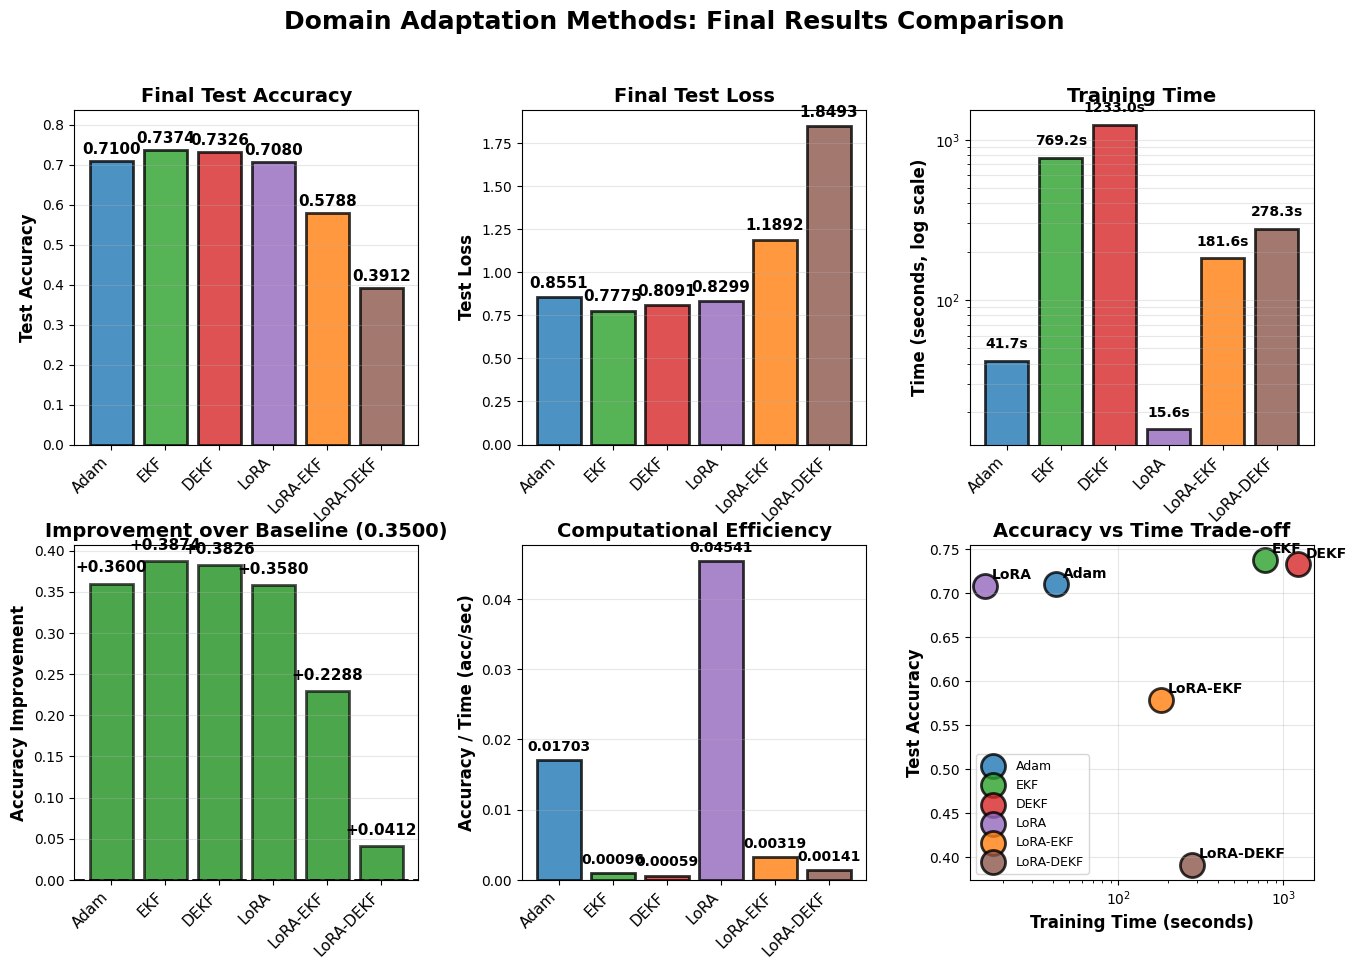

In [16]:
# ============================================================================
# SIMPLIFIED RESULTS VISUALIZATION (Final Metrics Only)
# ============================================================================

# Update results dictionary
results = {
    'adam': ft_results,
    'ekf': ekf_results,
    'dekf': dekf_results,
    'lora': lora_results,
    'lora_ekf': lora_ekf_results,
    'lora_dekf': lora_dekf_results
}

def plot_final_results(results):
    """
    Create visualization using only final metrics (no training dynamics)
    """
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

    methods = ['adam', 'ekf', 'dekf', 'lora', 'lora_ekf', 'lora_dekf']
    colors = {
        'adam': '#1f77b4',
        'ekf': '#2ca02c',
        'dekf': '#d62728',
        'lora': '#9467bd',
        'lora_ekf': '#ff7f0e',
        'lora_dekf': '#8c564b'
    }
    labels = {
        'adam': 'Adam',
        'ekf': 'EKF',
        'dekf': 'DEKF',
        'lora': 'LoRA',
        'lora_ekf': 'LoRA-EKF',
        'lora_dekf': 'LoRA-DEKF'
    }

    # ========================================================================
    # Plot 1: Final Test Accuracy (Bar Chart)
    # ========================================================================
    ax = fig.add_subplot(gs[0, 0])
    test_accs = [results[m].get('final_acc', results[m].get('test_acc', 0)) for m in methods]
    method_labels = [labels[m] for m in methods]
    bars = ax.bar(method_labels, test_accs, color=[colors[m] for m in methods],
                   alpha=0.8, edgecolor='black', linewidth=2)
    ax.set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
    ax.set_title('Final Test Accuracy', fontsize=14, fontweight='bold')
    ax.set_ylim([0, max(test_accs) + 0.1])
    
    # Add value labels on bars
    for i, (v, bar) in enumerate(zip(test_accs, bars)):
        ax.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom',
                fontweight='bold', fontsize=11)
    
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=11)

    # ========================================================================
    # Plot 2: Final Test Loss (Bar Chart)
    # ========================================================================
    ax = fig.add_subplot(gs[0, 1])
    test_losses = [results[m].get('final_loss', results[m].get('test_loss', 0)) for m in methods]
    bars = ax.bar(method_labels, test_losses, color=[colors[m] for m in methods],
                   alpha=0.8, edgecolor='black', linewidth=2)
    ax.set_ylabel('Test Loss', fontsize=12, fontweight='bold')
    ax.set_title('Final Test Loss', fontsize=14, fontweight='bold')
    
    # Add value labels
    for i, (v, bar) in enumerate(zip(test_losses, bars)):
        ax.text(i, v + max(test_losses)*0.02, f'{v:.4f}', ha='center', va='bottom',
                fontweight='bold', fontsize=11)
    
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=11)

    # ========================================================================
    # Plot 3: Training Time (Bar Chart with log scale)
    # ========================================================================
    ax = fig.add_subplot(gs[0, 2])
    times = [results[m].get('time', 0) for m in methods]
    bars = ax.bar(method_labels, times, color=[colors[m] for m in methods],
                   alpha=0.8, edgecolor='black', linewidth=2)
    ax.set_ylabel('Time (seconds, log scale)', fontsize=12, fontweight='bold')
    ax.set_title('Training Time', fontsize=14, fontweight='bold')
    ax.set_yscale('log')
    
    # Add value labels
    for i, (v, bar) in enumerate(zip(times, bars)):
        ax.text(i, v * 1.15, f'{v:.1f}s', ha='center', va='bottom',
                fontweight='bold', fontsize=10)
    
    ax.grid(True, alpha=0.3, axis='y', which='both')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=11)

    # ========================================================================
    # Plot 4: Accuracy Improvement over Baseline
    # ========================================================================
    ax = fig.add_subplot(gs[1, 0])
    
    # You need to set this - your baseline accuracy on shifted data
    baseline_shift_acc = 0.35  
    
    improvements = [results[m].get('final_acc', results[m].get('test_acc', 0)) - baseline_shift_acc 
                    for m in methods]
    
    # Color bars: green if positive, red if negative
    bar_colors = ['green' if imp > 0 else 'red' for imp in improvements]
    bars = ax.bar(method_labels, improvements, color=bar_colors,
                   alpha=0.7, edgecolor='black', linewidth=2)
    
    ax.set_ylabel('Accuracy Improvement', fontsize=12, fontweight='bold')
    ax.set_title(f'Improvement over Baseline ({baseline_shift_acc:.4f})', 
                 fontsize=14, fontweight='bold')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=2)
    
    # Add value labels
    for i, (v, bar) in enumerate(zip(improvements, bars)):
        label = f'+{v:.4f}' if v > 0 else f'{v:.4f}'
        y_pos = v + 0.01 if v > 0 else v - 0.01
        va = 'bottom' if v > 0 else 'top'
        ax.text(i, y_pos, label, ha='center', va=va,
                fontweight='bold', fontsize=11)
    
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=11)

    # ========================================================================
    # Plot 5: Computational Efficiency (Accuracy per Second)
    # ========================================================================
    ax = fig.add_subplot(gs[1, 1])
    efficiency = []
    valid_methods = []
    
    for m in methods:
        acc = results[m].get('final_acc', results[m].get('test_acc', 0))
        time_val = results[m].get('time', 1)
        if time_val > 0:
            efficiency.append(acc / time_val)
            valid_methods.append(m)
    
    if efficiency:
        method_labels_eff = [labels[m] for m in valid_methods]
        bars = ax.bar(method_labels_eff, efficiency, 
                       color=[colors[m] for m in valid_methods],
                       alpha=0.8, edgecolor='black', linewidth=2)
        ax.set_ylabel('Accuracy / Time (acc/sec)', fontsize=12, fontweight='bold')
        ax.set_title('Computational Efficiency', fontsize=14, fontweight='bold')
        
        # Add value labels
        for i, (v, bar) in enumerate(zip(efficiency, bars)):
            ax.text(i, v + max(efficiency)*0.02, f'{v:.5f}', ha='center', va='bottom',
                    fontweight='bold', fontsize=10)
        
        ax.grid(True, alpha=0.3, axis='y')
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=11)

    # ========================================================================
    # Plot 6: Performance vs Time Trade-off (Scatter)
    # ========================================================================
    ax = fig.add_subplot(gs[1, 2])
    
    for m in methods:
        acc = results[m].get('final_acc', results[m].get('test_acc', 0))
        time_val = results[m].get('time', 0)
        ax.scatter(time_val, acc, color=colors[m], s=300, 
                   edgecolor='black', linewidth=2, alpha=0.8, label=labels[m])
        
        # Add method labels
        ax.annotate(labels[m], (time_val, acc), 
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Training Time (seconds)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
    ax.set_title('Accuracy vs Time Trade-off', fontsize=14, fontweight='bold')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='best')

    # ========================================================================
    # Overall Title
    # ========================================================================
    plt.suptitle('Domain Adaptation Methods: Final Results Comparison',
                 fontsize=18, fontweight='bold', y=0.98)

    print("\n✓ Results saved: /mnt/user-data/outputs/final_results_comparison.png")
    plt.show()

# Generate plots
plot_final_results(results)

In [18]:
# =====================================
# COMPREHENSIVE EXPERIMENT SUMMARY
# =====================================
import pandas as pd

print("\n" + "="*100)
print("COMPREHENSIVE EXPERIMENT SUMMARY")
print("="*100)

# ------------------------------------------------------------
# Gather metrics from all methods
# ------------------------------------------------------------
adam_results = ft_results
pretrain_acc = test_acc
train_loss = 0.8
# Baseline metrics (before adaptation)
baseline_clean_acc = pretrain_acc          # Accuracy on clean test set after pretraining
baseline_shift_acc = baseline_acc_shift    # Accuracy on shifted test set (no adaptation)

methods = ['Baseline (Shifted)', 'Adam', 'EKF', 'DEKF', 'LoRA', 'LoRA-EKF', 'LoRA-DEKF']

summary_data = {
    'Method': methods,
    'Epochs': [
        '-',
        adam_results.get('epochs', '-'),
        ekf_results.get('epochs', '-'),
        dekf_results.get('epochs', '-'),
        lora_results.get('epochs', '-'),
        lora_ekf_results.get('epochs', '-'),
        lora_dekf_results.get('epochs', '-'),
    ],
    'Batch Size': [
        '-',
        128,
        128,
        128,
        128,
        128,
        128,
    ],
    'Train Acc (Final)': [
        '-',
        adam_results['accs'][-1] if 'accs' in adam_results else '-',
        ekf_results['accs'][-1] if 'accs' in ekf_results else '-',
        dekf_results['accs'][-1] if 'accs' in dekf_results else '-',
        lora_results['accs'][-1] if 'accs' in lora_results else '-',
        lora_ekf_results['accs'][-1] if 'accs' in lora_ekf_results else '-',
        lora_dekf_results['accs'][-1] if 'accs' in lora_dekf_results else '-',
    ],
    'Test Acc (Final)': [
        baseline_shift_acc,
        adam_results.get('final_acc', adam_results.get('test_acc')),
        ekf_results.get('final_acc', ekf_results.get('test_acc')),
        dekf_results.get('final_acc', dekf_results.get('test_acc')),
        lora_results.get('final_acc', lora_results.get('test_acc')),
        lora_ekf_results.get('final_acc', lora_ekf_results.get('test_acc')),
        lora_dekf_results.get('final_acc', lora_dekf_results.get('test_acc')),
    ],
    'Test Loss (Final)': [
        '-',
        adam_results.get('final_loss', adam_results.get('test_loss')),
        ekf_results.get('final_loss', ekf_results.get('test_loss')),
        dekf_results.get('final_loss', dekf_results.get('test_loss')),
        lora_results.get('final_loss', lora_results.get('test_loss')),
        lora_ekf_results.get('final_loss', lora_ekf_results.get('test_loss')),
        lora_dekf_results.get('final_loss', lora_dekf_results.get('test_loss')),
    ],
    'Time (sec)': [
        '-',
        adam_results.get('time', '-'),
        ekf_results.get('time', '-'),
        dekf_results.get('time', '-'),
        lora_results.get('time', '-'),
        lora_ekf_results.get('time', '-'),
        lora_dekf_results.get('time', '-'),
    ],
    'Improvement': [
        0.0,
        adam_results.get('final_acc', 0) - baseline_shift_acc,
        ekf_results.get('final_acc', 0) - baseline_shift_acc,
        dekf_results.get('final_acc', 0) - baseline_shift_acc,
        lora_results.get('final_acc', 0) - baseline_shift_acc,
        lora_ekf_results.get('final_acc', 0) - baseline_shift_acc,
        lora_dekf_results.get('final_acc', 0) - baseline_shift_acc,
    ],
}

summary_df = pd.DataFrame(summary_data)

print("\n MAIN RESULTS TABLE")
print("-" * 100)
print(summary_df)
print(summary_df.to_string(index=False))

# ------------------------------------------------------------
# Additional Statistics
# ------------------------------------------------------------
print("\n\n ADDITIONAL STATISTICS")
print("-" * 100)

classifier_params = 2410
lora_params = 1146
total_model_params = 17850

stats_data = {
    'Metric': [
        'Total Model Parameters',
        'Classifier Parameters',
        'LoRA Trainable Parameters',
        'LoRA Efficiency (%)',
        '',
        'Training Data Size',
        'Test Data Size',
        'Domain Shift',
        '',
        'Baseline (Clean) Accuracy',
        'Baseline (Shifted) Accuracy',
        'Accuracy Drop (Shift)',
    ],
    'Value': [
        f"{total_model_params:,}",
        f"{classifier_params:,}",
        f"{lora_params:,}",
        f"{100 * lora_params / classifier_params:.2f}%",
        '',
        "20,000 samples",
        "5,000 samples",
        "Rotation=45°, Contrast=1.8, Brightness=0.4",
        '',
        f"{baseline_clean_acc:.4f}",
        f"{baseline_shift_acc:.4f}",
        f"{baseline_clean_acc - baseline_shift_acc:.4f}",
    ]
}

stats_df = pd.DataFrame(stats_data)
print(stats_df.to_string(index=False, header=False))

# ------------------------------------------------------------
# Ranking by Performance
# ------------------------------------------------------------
print("\n\n RANKING BY TEST ACCURACY")
print("-" * 100)

accuracies = [
    ('Baseline (Shifted)', baseline_shift_acc),
    ('Adam', adam_results.get('final_acc', 0)),
    ('EKF', ekf_results.get('final_acc', 0)),
    ('DEKF', dekf_results.get('final_acc', 0)),
    ('LoRA', lora_results.get('final_acc', 0)),
    ('LoRA-EKF', lora_ekf_results.get('final_acc', 0)),
    ('LoRA-DEKF', lora_dekf_results.get('final_acc', 0)),
]

accuracies_sorted = sorted(accuracies, key=lambda x: x[1], reverse=True)

ranking_df = pd.DataFrame({
    'Rank': range(1, len(accuracies_sorted) + 1),
    'Method': [x[0] for x in accuracies_sorted],
    'Test Accuracy': [f"{x[1]:.4f}" for x in accuracies_sorted],
    'vs Baseline': [f"{x[1] - baseline_shift_acc:+.4f}" for x in accuracies_sorted],
})

print(ranking_df.to_string(index=False))

# ------------------------------------------------------------
# Ranking by Efficiency
# ------------------------------------------------------------
print("\n\n RANKING BY EFFICIENCY (Accuracy / sec)")
print("-" * 100)

efficiency = [
    ('Adam', adam_results['final_acc'] / adam_results['time']),
    ('EKF', ekf_results['final_acc'] / ekf_results['time']),
    ('DEKF', dekf_results['final_acc'] / dekf_results['time']),
    ('LoRA', lora_results['final_acc'] / lora_results['time']),
    ('LoRA-EKF', lora_ekf_results['final_acc'] / lora_ekf_results['time']),
    ('LoRA-DEKF', lora_dekf_results['final_acc'] / lora_dekf_results['time']),
]

efficiency_sorted = sorted(efficiency, key=lambda x: x[1], reverse=True)

times_dict = {
    'Adam': adam_results['time'],
    'EKF': ekf_results['time'],
    'DEKF': dekf_results['time'],
    'LoRA': lora_results['time'],
    'LoRA-EKF': lora_ekf_results['time'],
    'LoRA-DEKF': lora_dekf_results['time'],
}

eff_df = pd.DataFrame({
    'Rank': range(1, len(efficiency_sorted) + 1),
    'Method': [x[0] for x in efficiency_sorted],
    'Efficiency': [f"{x[1]:.6f}" for x in efficiency_sorted],
    'Time (sec)': [f"{times_dict[x[0]]:.2f}" for x in efficiency_sorted],
})

print(eff_df.to_string(index=False))

# ------------------------------------------------------------
# KEY INSIGHTS
# ------------------------------------------------------------
print("\n\n KEY INSIGHTS")
print("-" * 100)

best_method = accuracies_sorted[0]
most_efficient = efficiency_sorted[0]

print(f"✓ Best Accuracy: {best_method[0]} ({best_method[1]:.4f})")
print(f"✓ Most Efficient: {most_efficient[0]} ({most_efficient[1]:.6f} acc/s)")
print(f"✓ Max Gain Over Baseline: {max(x[1] - baseline_shift_acc for x in accuracies):.4f}")

print("\n" + "="*100 + "\n")


COMPREHENSIVE EXPERIMENT SUMMARY

 MAIN RESULTS TABLE
----------------------------------------------------------------------------------------------------
               Method Epochs Batch Size Train Acc (Final)  Test Acc (Final)  \
0  Baseline (Shifted)      -          -                 -            0.4960   
1                Adam    100        128                 -            0.7100   
2                 EKF      1        128                 -            0.7374   
3                DEKF      1        128                 -            0.7326   
4                LoRA     20        128           0.78125            0.7080   
5            LoRA-EKF      1        128                 -            0.5788   
6           LoRA-DEKF      1        128                 -            0.3912   

  Test Loss (Final)   Time (sec)  Improvement  
0                 -            -       0.0000  
1          0.855065    41.687764       0.2140  
2           0.77752   769.191655       0.2414  
3          0.809141